Task 1 - Data Preparation:

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# using the provided code from assignment_1_updated_code.py
from assignment_1_updated_code import fff_injection_df, rpm_injection_df, no_injection_df
print("CAN Bus log - injection of FFF as the speed reading.log")



CAN Bus log - injection of FFF as the speed reading.log


In [18]:
fff_injection_df.head()

,RPM,Speed,attack
0,626.0,False,0
1,False,0.0,0
2,624.0,False,0
3,False,0.0,0
4,624.0,False,0


In [19]:
rpm_injection_df.head()

,RPM,Speed,attack
0,740.0,False,0
1,False,5.312724,0
2,742.0,False,0
3,False,5.312724,0
4,744.0,False,0


In [20]:
no_injection_df.head()

,RPM,Speed,attack
0,636.0,False,0
1,False,0.0,0
2,640.0,False,0
3,False,0.0,0
4,640.0,False,0


Task 2 - Step 1 (Plotting changes over time and relationships):

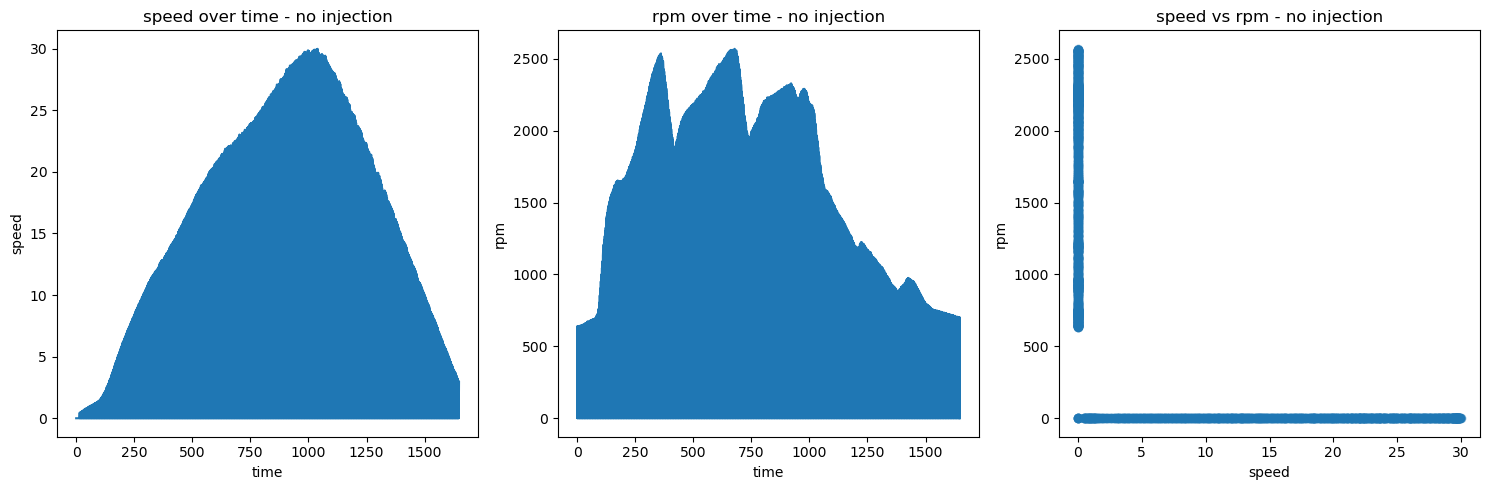

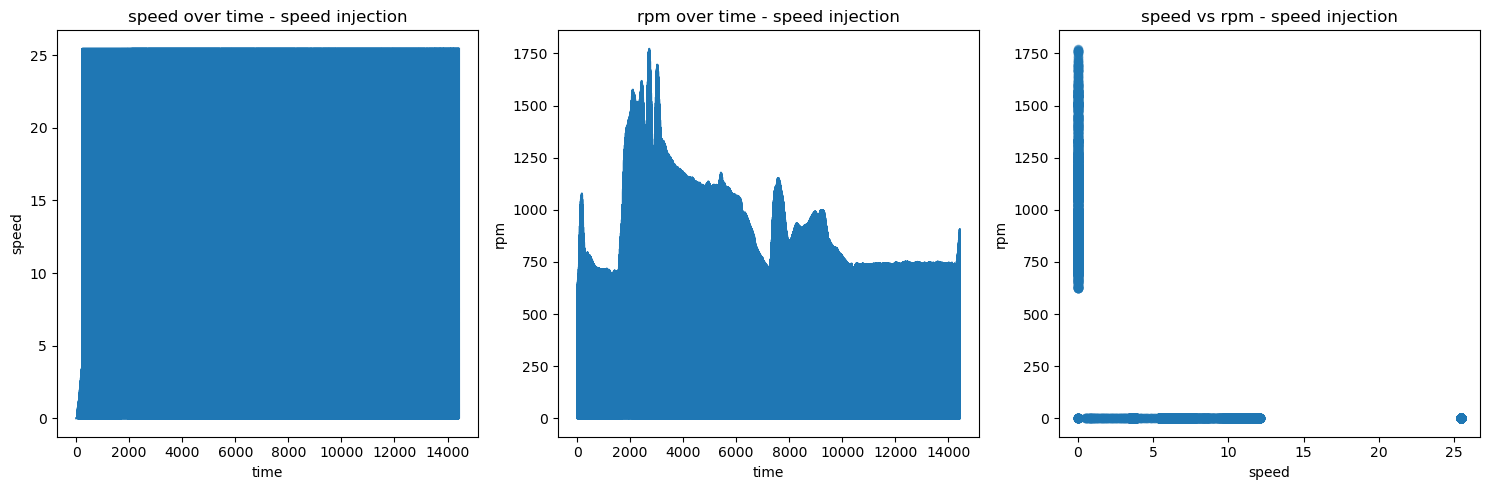

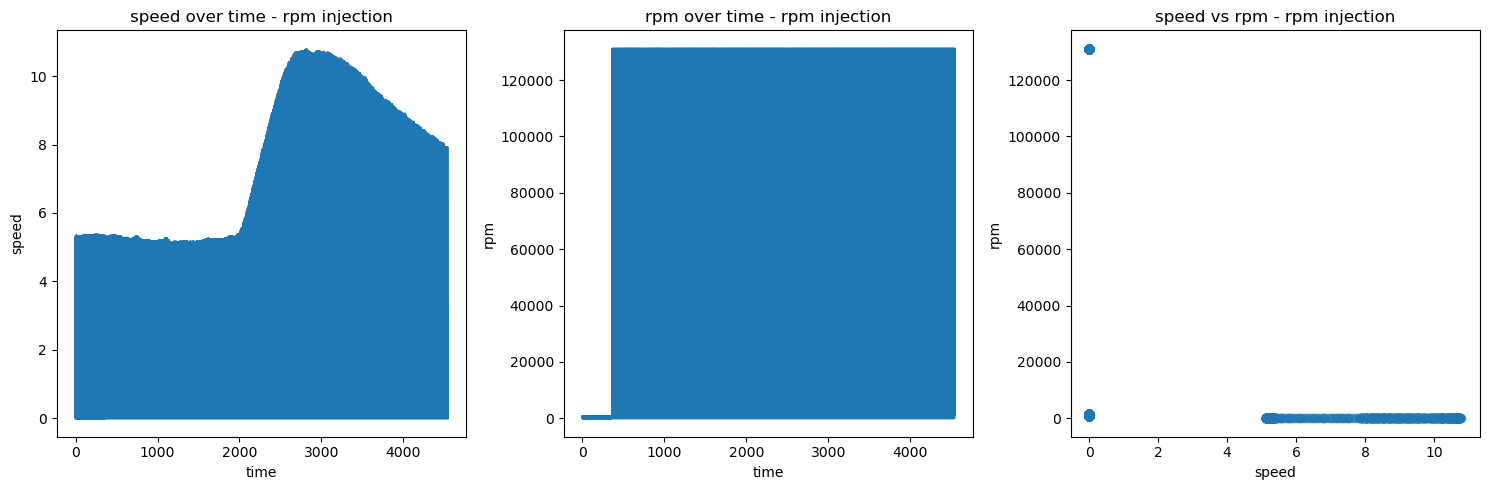

In [13]:
plt.figure(figsize=(15, 5))

# no injection plots
plt.subplot(131)
plt.plot(no_injection_df['Speed'].dropna())
plt.title('speed over time - no injection')
plt.xlabel('time')
plt.ylabel('speed')

plt.subplot(132)
plt.plot(no_injection_df['RPM'].dropna())
plt.title('rpm over time - no injection')
plt.xlabel('time')
plt.ylabel('rpm')

plt.subplot(133)
plt.scatter(no_injection_df['Speed'].dropna(), no_injection_df['RPM'].dropna(), alpha=0.5)
plt.title('speed vs rpm - no injection')
plt.xlabel('speed')
plt.ylabel('rpm')

plt.tight_layout()
plt.show()

# fff injection plots
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.plot(fff_injection_df['Speed'].dropna())
plt.title('speed over time - speed injection')
plt.xlabel('time')
plt.ylabel('speed')

plt.subplot(132)
plt.plot(fff_injection_df['RPM'].dropna())
plt.title('rpm over time - speed injection')
plt.xlabel('time')
plt.ylabel('rpm')

plt.subplot(133)
plt.scatter(fff_injection_df['Speed'].dropna(), fff_injection_df['RPM'].dropna(), alpha=0.5)
plt.title('speed vs rpm - speed injection')
plt.xlabel('speed')
plt.ylabel('rpm')

plt.tight_layout()
plt.show()

# rpm injection plots
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.plot(rpm_injection_df['Speed'].dropna())
plt.title('speed over time - rpm injection')
plt.xlabel('time')
plt.ylabel('speed')

plt.subplot(132)
plt.plot(rpm_injection_df['RPM'].dropna())
plt.title('rpm over time - rpm injection')
plt.xlabel('time')
plt.ylabel('rpm')

plt.subplot(133)
plt.scatter(rpm_injection_df['Speed'].dropna(), rpm_injection_df['RPM'].dropna(), alpha=0.5)
plt.title('speed vs rpm - rpm injection')
plt.xlabel('speed')
plt.ylabel('rpm')

plt.tight_layout()
plt.show()


Task 2 - Step 2 (Frequency plots):

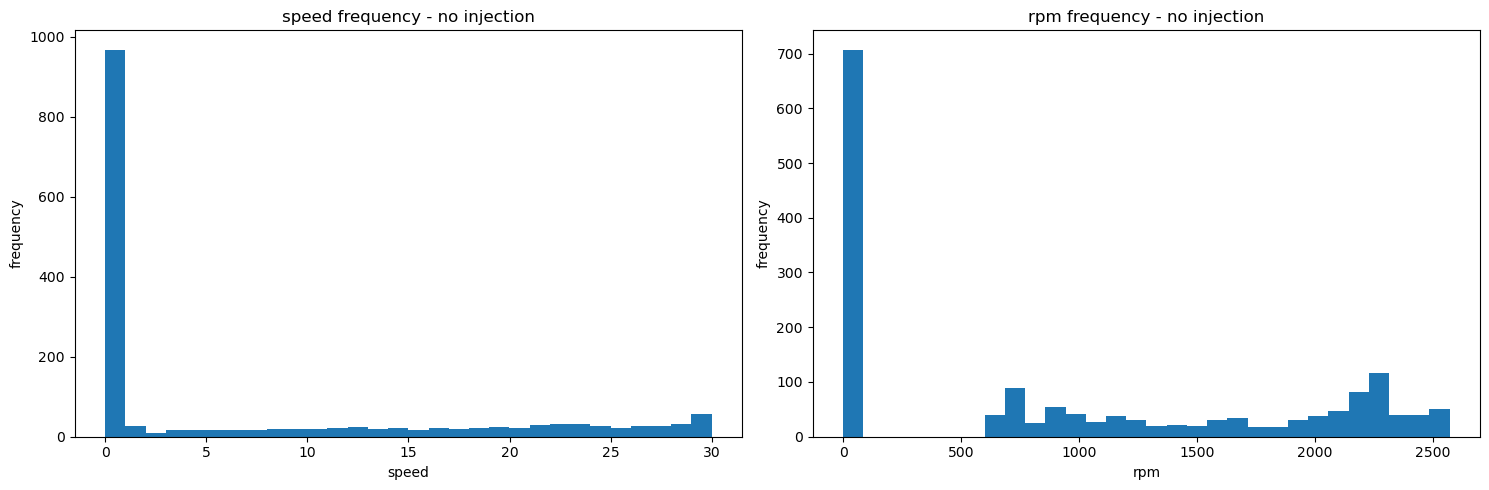

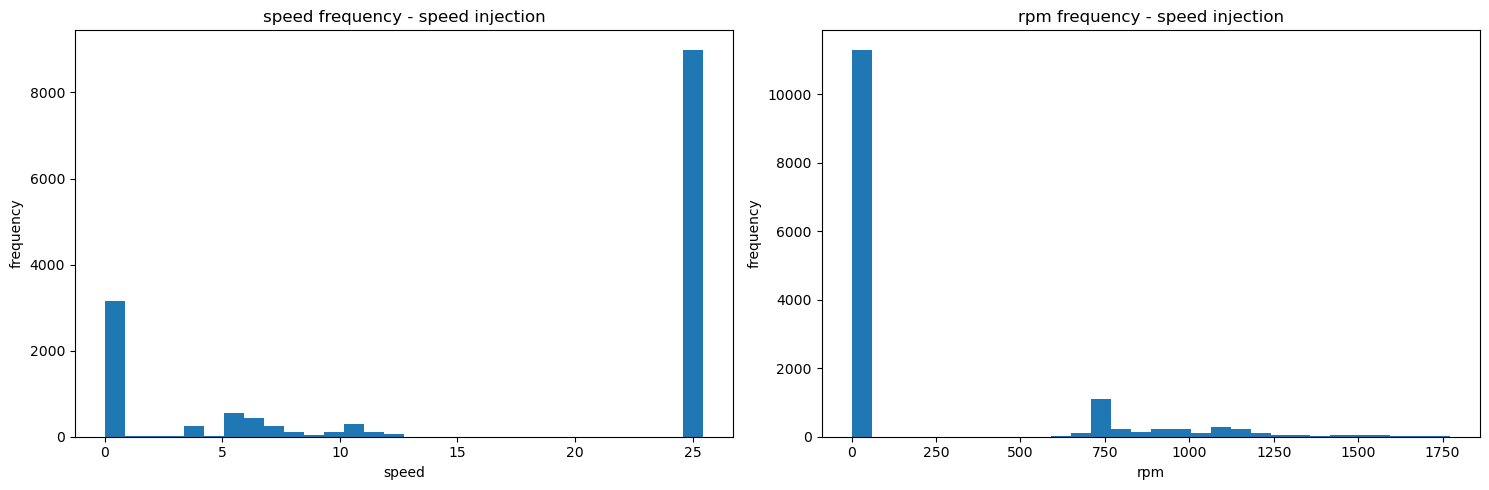

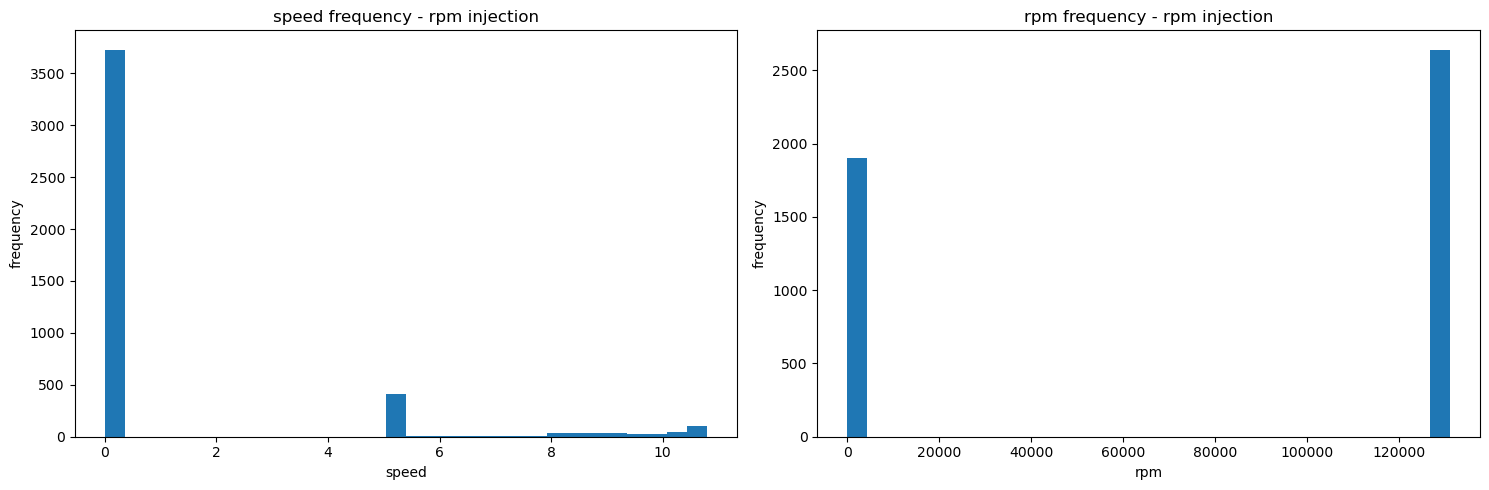

In [14]:
plt.figure(figsize=(15, 5))

# no injection frequency plots
plt.subplot(121)
plt.hist(no_injection_df['Speed'].dropna(), bins=30)
plt.title('speed frequency - no injection')
plt.xlabel('speed')
plt.ylabel('frequency')

plt.subplot(122)
plt.hist(no_injection_df['RPM'].dropna(), bins=30)
plt.title('rpm frequency - no injection')
plt.xlabel('rpm')
plt.ylabel('frequency')

plt.tight_layout()
plt.show()

# fff injection frequency plots
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.hist(fff_injection_df['Speed'].dropna(), bins=30)
plt.title('speed frequency - speed injection')
plt.xlabel('speed')
plt.ylabel('frequency')

plt.subplot(122)
plt.hist(fff_injection_df['RPM'].dropna(), bins=30)
plt.title('rpm frequency - speed injection')
plt.xlabel('rpm')
plt.ylabel('frequency')

plt.tight_layout()
plt.show()

# rpm injection frequency plots
plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.hist(rpm_injection_df['Speed'].dropna(), bins=30)
plt.title('speed frequency - rpm injection')
plt.xlabel('speed')
plt.ylabel('frequency')

plt.subplot(122)
plt.hist(rpm_injection_df['RPM'].dropna(), bins=30)
plt.title('rpm frequency - rpm injection')
plt.xlabel('rpm')
plt.ylabel('frequency')

plt.tight_layout()
plt.show()


Task 2 - Step 3 (Correlation analysis):

In [15]:
def calculate_correlation(df):
    speed = df['Speed'].dropna()
    rpm = df['RPM'].dropna()
    # ensure same length by using common indices
    common_idx = speed.index.intersection(rpm.index)
    speed = speed[common_idx]
    rpm = rpm[common_idx]
    correlation, p_value = stats.pearsonr(speed, rpm)
    return correlation, p_value

# calculate correlations for all three scenarios
no_inj_corr, no_inj_p = calculate_correlation(no_injection_df)
fff_inj_corr, fff_inj_p = calculate_correlation(fff_injection_df)
rpm_inj_corr, rpm_inj_p = calculate_correlation(rpm_injection_df)

# create correlation results dataframe
correlation_results = pd.DataFrame({
    'scenario': ['no injection', 'speed injection', 'rpm injection'],
    'correlation': [no_inj_corr, fff_inj_corr, rpm_inj_corr],
    'p_value': [no_inj_p, fff_inj_p, rpm_inj_p]
})

print(correlation_results)


          scenario  correlation        p_value
0     no injection    -0.704439  1.700339e-247
1  speed injection    -0.768675   0.000000e+00
2    rpm injection    -0.526325  3.162020e-322


In [16]:
from sklearn.linear_model import LogisticRegression
import joblib

# Assuming you already have the dataframe like: no_injection_df
# with columns ['RPM', 'Speed', 'attack']

# Split data into features and labels
X = no_injection_df.drop(['attack'], axis=1).values
y = no_injection_df['attack'].values

# Train a logistic regression model
clf = LogisticRegression(max_iter=1000, random_state=0)
clf.fit(X, y)

# Save the trained model
joblib.dump(clf, "./logistic_regression.joblib")


['./logistic_regression.joblib']